In [2]:
install.packages("tidyverse")

Installing package into ‘/Users/gh13047/Library/R/arm64/4.5/library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘bit’, ‘bit64’, ‘blob’, ‘DBI’, ‘gargle’, ‘ids’, ‘rematch2’, ‘vroom’, ‘tzdb’, ‘selectr’, ‘conflicted’, ‘dbplyr’, ‘dtplyr’, ‘googledrive’, ‘googlesheets4’, ‘haven’, ‘readr’, ‘reprex’, ‘rvest’





The downloaded binary packages are in
	/var/folders/pw/g0vwt8t10t33bmdcrhnws2lr0000gp/T//RtmpagaszD/downloaded_packages


In [ ]:
library(tidyverse)

simulate_time_to_event <- function(liability, baseline_rate = 0.1, shape = 1) {
  #' Simulate time-to-event data based on individual liability
  #' 
  #' @param liability Vector of individual liability values
  #' @param baseline_rate Baseline hazard rate (lambda parameter)
  #' @param shape Shape parameter for Weibull distribution (shape=1 gives exponential)
  #' @return Vector of simulated time to event for each individual
  
  n <- length(liability)
  
  # Convert liability to hazard rate (exponential relationship)
  # Higher liability = higher hazard = shorter time to event
  hazard_rate <- baseline_rate * exp(liability)
  
  # Scale parameter for Weibull (lambda = 1/scale)
  scale <- 1 / hazard_rate
  
  # Simulate time to event using Weibull distribution
  # When shape=1, this is exponential distribution
  time_to_event <- rweibull(n, shape = shape, scale = scale)
  
  return(time_to_event)
}

# Example simulation
set.seed(42)
n_individuals <- 1000

# Simulate liability (e.g., genetic risk, standardized)
liability <- rnorm(n_individuals, mean = 0, sd = 1)

# Simulate time to event
time_to_event <- simulate_time_to_event(liability, baseline_rate = 0.1, shape = 10)

# Create dataframe
df <- tibble(
  individual_id = 1:n_individuals,
  liability = liability,
  time_to_event = time_to_event
)


# A tibble: 10 × 3
   individual_id liability time_to_event
           <int>     <dbl>         <dbl>
 1             1    1.37            1.60
 2             2   -0.565          17.3 
 3             3    0.363           6.27
 4             4    0.633           4.29
 5             5    0.404           5.63
 6             6   -0.106           9.89
 7             7    1.51            2.03
 8             8   -0.0947          9.21
 9             9    2.02            1.41
10            10   -0.0627         10.7 

Mean time to event: 16.06721 
Median time to event: 9.735217 


In [34]:
set.seed(123)
n <- 1000

# Simulate genetic/environmental liability (standardized)
liability <- rnorm(n, mean = 0, sd = 1)

# For cancer with median onset around age 65-70:
# baseline_rate = 0.015 gives expected time ~ 67 years for liability=0
cancer_data <- tibble(
  person_id = 1:n,
  liability = liability,
  age_at_cancer1 = simulate_time_to_event(liability, baseline_rate = 0.003, shape = 1),
  age_at_cancer2 = simulate_time_to_event(liability, baseline_rate = 0.003, shape = 1),
  diff = abs(age_at_cancer1 - age_at_cancer2),
  below_60 = age_at_cancer1 < 60 | age_at_cancer2 < 60
)
str(cancer_data)

tibble [1,000 × 6] (S3: tbl_df/tbl/data.frame)
 $ person_id     : int [1:1000] 1 2 3 4 5 6 7 8 9 10 ...
 $ liability     : num [1:1000] -0.5605 -0.2302 1.5587 0.0705 0.1293 ...
 $ age_at_cancer1: num [1:1000] 1071 812 133 206 207 ...
 $ age_at_cancer2: num [1:1000] 922.9 24.8 68 145.4 496.6 ...
 $ diff          : num [1:1000] 148.2 786.8 65.5 61.1 289.4 ...
 $ below_60      : logi [1:1000] FALSE TRUE FALSE FALSE FALSE TRUE ...


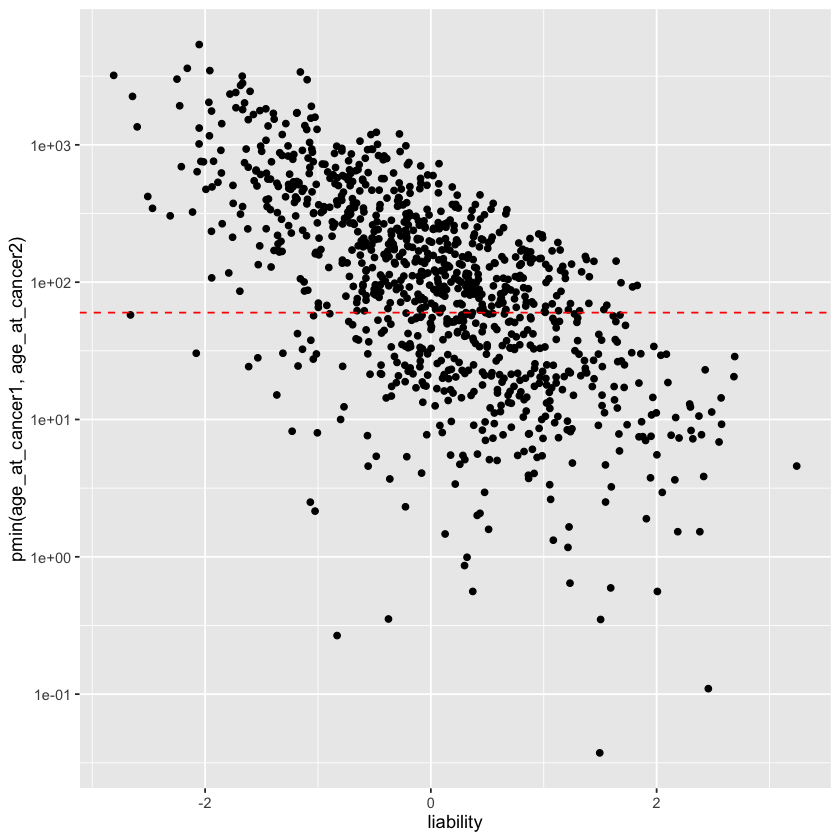

In [46]:
cancer_data %>%
    ggplot(aes(x = liability, y = pmin(age_at_cancer1, age_at_cancer2))) +
    geom_point() +
    scale_y_log10() +
    geom_hline(yintercept = 60, linetype = "dashed", color = "red")

In [47]:
table(cancer_data$below_60)


FALSE  TRUE 
  624   376 

In [51]:
cancer_data %>% group_by(below_60, diff <= 5) %>% summarise(n = n(), prop=n()/nrow(cancer_data))

`summarise()` has grouped output by 'below_60'. You can override using the
`.groups` argument.


below_60,diff <= 5,n,prop
<lgl>,<lgl>,<int>,<dbl>
FALSE,FALSE,613,0.613
FALSE,TRUE,11,0.011
TRUE,FALSE,365,0.365
TRUE,TRUE,11,0.011


In [52]:
set.seed(123)
n <- 1000

# Simulate genetic/environmental liability (standardized)
liability <- rnorm(n, mean = 0, sd = 3)

# For cancer with median onset around age 65-70:
# baseline_rate = 0.015 gives expected time ~ 67 years for liability=0
cancer_data <- tibble(
  person_id = 1:n,
  liability = liability,
  age_at_cancer1 = simulate_time_to_event(liability, baseline_rate = 0.003, shape = 1),
  age_at_cancer2 = simulate_time_to_event(liability, baseline_rate = 0.003, shape = 1),
  diff = abs(age_at_cancer1 - age_at_cancer2),
  below_60 = age_at_cancer1 < 60 | age_at_cancer2 < 60
)
cancer_data %>% group_by(below_60, diff <= 5) %>% summarise(n = n(), prop=n()/nrow(cancer_data))

`summarise()` has grouped output by 'below_60'. You can override using the
`.groups` argument.


below_60,diff <= 5,n,prop
<lgl>,<lgl>,<int>,<dbl>
FALSE,FALSE,536,0.536
FALSE,TRUE,5,0.005
TRUE,FALSE,328,0.328
TRUE,TRUE,131,0.131


When the liability has a low variance (i.e. not contributing much to overall risk, most risk comes from chance), then bilateral cancer incidence within 5 years is at 1%. 

When liability has a high variance (i.e. smaller chance component) then bilateral cancer incidence within 5 years is at 13%.

One way to determine if bilateral cancer is occurring more than expected is to look at familial rates. Suppose siblings share ~50% genetics and X% environmental liability, we can get expected and observed rates for bilateral cancer and sibling cancer.